## Imports

In [47]:
%load_ext autoreload
%autoreload 2

import logging

import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import helpers.hmodule as hmodule

import msml610_utils as ut
import L08_02_causal_inference_utils as mtl0cireout

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0


Python 3.12.3
Linux c804b4f4dbf3 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


INFO:msml610_utils:preliz version=0.19.0


In [49]:
hmodule.install_module_if_not_present(
    "dataframe_image",
    use_activate=True,
)

hmodule.install_module_if_not_present(
    "networkx",
    use_activate=True,
)

hmodule.install_module_if_not_present(
    "pgmpy",
    use_activate=True,
)

Module 'dataframe_image' is already installed.
Module 'networkx' is already installed.
Module 'pgmpy' is already installed.


In [50]:
import networkx as nx

import pgmpy.base as pgmpy_base

# Causal Roles Explorer

In [63]:
# Display interactive causal roles explorer: select a graph, treatment, and
# outcome to highlight confounders, mediators, and colliders.
mtl0cireout.causal_roles_explorer()

# Cell

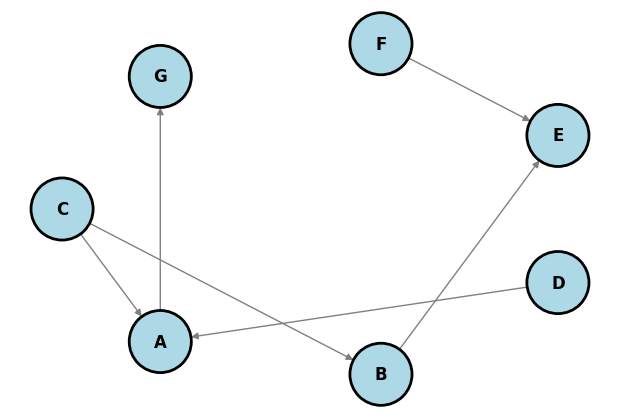

In [51]:
model = nx.DiGraph(
    [
        ("C", "A"),
        ("C", "B"),
        ("D", "A"),
        ("B", "E"),
        ("F", "E"),
        ("A", "G"),
    ]
)

mtl0cireout.plot_graph_highlight(model)

In [52]:
# Convert your NetworkX graph to pgmpy DAG.
dag = pgmpy_base.DAG(model.edges())

print("Are D and C dependent?")
print(not dag.is_dconnected("D", "C"))

Are D and C dependent?
True


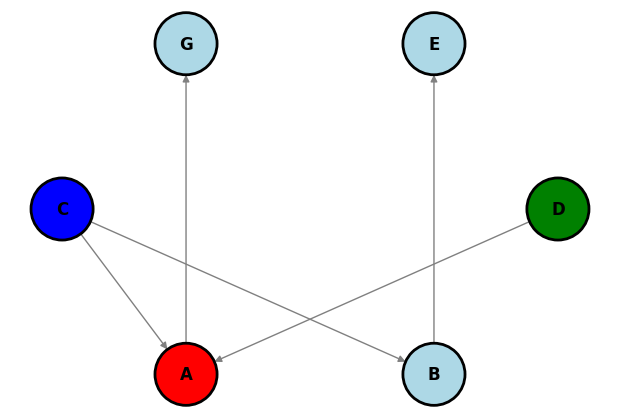

In [53]:
subgraph = mtl0cireout.reachable_subgraph(model, ["A", "D", "C"])
mtl0cireout.plot_graph_highlight(
    subgraph,
    node1="D",
    node2="C",
    conditioning_node_set=["A"],
)

In [54]:
print("Are D and C dependent given A?")
print(not dag.is_dconnected("D", "C", observed={"A"}))

Are D and C dependent given A?
False


In [55]:
print("Are D and C dependent given G?")
print(not dag.is_dconnected("D", "C", observed={"G"}))

Are D and C dependent given G?
False


In [56]:
print("Are G and D dependent?")
print(not dag.is_dconnected("G", "D"))

Are G and D dependent?
False


In [57]:
print("Are G and D dependent given A?")
print(not dag.is_dconnected("G", "D", observed=["A"]))

Are G and D dependent given A?
True


In [58]:
print("Are G and F dependent?")
print(dag.is_dconnected("G", "F"))

Are G and F dependent?
False


In [59]:
print("Are G and F dependent given E?")
print(dag.is_dconnected("G", "F", observed=["E"]))

Are G and F dependent given E?
True


# Interactive D-Separation Explorer

In [61]:
# Display interactive d-separation explorer for node1, node2, and conditioning
# set (use shift to select multiple conditioning nodes).
mtl0cireout.d_separation_explorer(
    model,
    dag,
    default_node1="D",
    default_node2="C",
    default_conditioning=["A"],
)